<a href="https://colab.research.google.com/github/2023006766/deep-learning/blob/main/RNN_backward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch: 100, Loss: 0.9361
Epoch: 200, Loss: 0.2706
Epoch: 300, Loss: 0.1018
Epoch: 400, Loss: 0.0555
Epoch: 500, Loss: 0.0369
Epoch: 600, Loss: 0.0274
Epoch: 700, Loss: 0.0216
Epoch: 800, Loss: 0.0179
Epoch: 900, Loss: 0.0152
Epoch: 1000, Loss: 0.0132

Final Loss: 0.0132
Final Predictions (Target index vs Predicted index):
Step 1: Target 1, Pred 1 | [0. 1. 0.]
Step 2: Target 2, Pred 2 | [0.   0.   0.99]
Step 3: Target 0, Pred 0 | [1. 0. 0.]


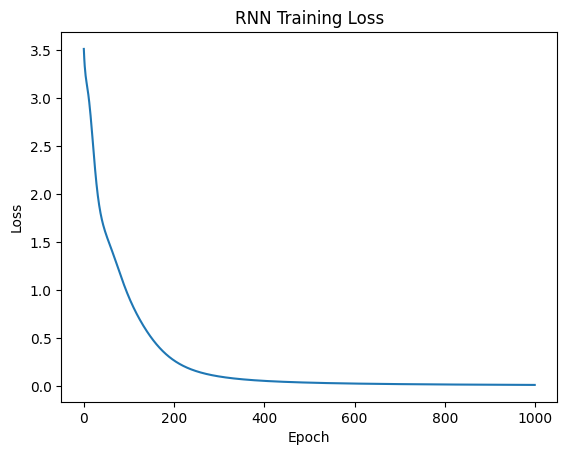

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set print options for cleaner output
np.set_printoptions(suppress=True)

# 1. Activation and Loss Functions
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

def clip_gradients(grad, value):
    return np.clip(grad, -value, value)

# 2. Parameters & Data Initialization
# FIXED: why must be (3, 2) to match the 3-class output and 2 hidden units
wxh = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]]) # (2, 3)
whh = np.array([[0.7, 0.8], [0.9, 1.0]])          # (2, 2)
why = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]]) # Changed from (2,2) to (3,2)
bh = np.array([[0.1], [0.2]])                     # (2, 1)
by = np.array([[0.1], [0.2], [0.3]])              # (3, 1)

# Inputs and Targets (One-hot encoded)
x1 = np.array([[1], [0], [0]])
x2 = np.array([[0], [1], [0]])
x3 = np.array([[0], [0], [1]])
inputs = [x1, x2, x3]

t1 = np.array([[0], [1], [0]])
t2 = np.array([[0], [0], [1]])
t3 = np.array([[1], [0], [0]])
targets = [t1, t2, t3]

learning_rate = 0.1
max_epochs = 1000
clip_value = 5.0
loss_history = []

# 3. Training Loop
for epoch in range(max_epochs):
    h0 = np.zeros((2, 1))
    hs = [h0]
    ps = []
    loss = 0

    # Forward Pass
    for t in range(3):
        # Hidden state: tanh(wxh * x + whh * h_prev + bh)
        ht = np.tanh(np.dot(wxh, inputs[t]) + np.dot(whh, hs[t]) + bh)
        # Output: why * ht + by
        y = np.dot(why, ht) + by # Now (3,2) * (2,1) + (3,1) = (3,1)
        p = softmax(y)

        hs.append(ht)
        ps.append(p)
        loss += cross_entropy(targets[t], p)

    loss_history.append(loss)

    # 4. Backward Pass (BPTT)
    dwxh, dwhh, dwhy = np.zeros_like(wxh), np.zeros_like(whh), np.zeros_like(why)
    dbh, dby = np.zeros_like(bh), np.zeros_like(by)
    dh_next = np.zeros((2, 1))

    for t in reversed(range(3)):
        dy = ps[t] - targets[t]
        dwhy += np.dot(dy, hs[t+1].T)
        dby += dy

        dh = np.dot(why.T, dy) + dh_next
        dh_raw = (1 - hs[t+1]**2) * dh # tanh derivative

        dbh += dh_raw
        dwxh += np.dot(dh_raw, inputs[t].T)
        dwhh += np.dot(dh_raw, hs[t].T)
        dh_next = np.dot(whh.T, dh_raw)

    # Gradient Clipping & Update Weights
    for grad, param in zip([dwxh, dwhh, dwhy, dbh, dby], [wxh, whh, why, bh, by]):
        param -= learning_rate * clip_gradients(grad, clip_value)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch: {epoch + 1}, Loss: {loss:.4f}")

# 5. Final Output & Visualization
print(f"\nFinal Loss: {loss:.4f}")
print("Final Predictions (Target index vs Predicted index):")
for t in range(3):
    target_idx = np.argmax(targets[t])
    pred_idx = np.argmax(ps[t])
    print(f"Step {t+1}: Target {target_idx}, Pred {pred_idx} | {np.round(ps[t], 2).flatten()}")

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Loss")
plt.show()